In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.normalized_env_new import CoppeliaSimEnv
import os

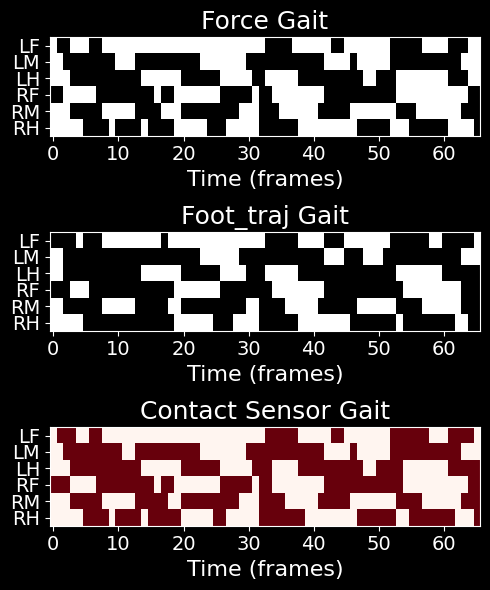

In [21]:
data = pd.read_csv('experttemp.csv', header=[0], index_col=None)

def plot_gait(expert, start, end):
    force_cols = ['force_FL', 'force_ML', 'force_HL', 'force_FR', 'force_MR', 'force_HR']
    foot_cols = ['FL_foot_traj_z', 'ML_foot_traj_z', 'HL_foot_traj_z', 'FR_foot_traj_z', 'MR_foot_traj_z', 'HR_foot_traj_z']
    contact_cols = ['contact_info_FL', 'contact_info_ML', 'contact_info_HL', 'contact_info_FR', 'contact_info_MR', 'contact_info_HR']
    leg_labels = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']

    def get_contact_byforce(data):
        """Compute binary contact states (1=stance, 0=swing)."""
        contact = np.zeros((len(data), len(force_cols)))
        for i, col in enumerate(force_cols):
            contact[:, i] = (data[col].abs() > 0.27).astype(int)
        return contact[start:end]
    
    def get_contact_byfoot(data):
        """Compute binary contact states (1=stance, 0=swing)."""
        contact = np.zeros((len(data), len(foot_cols)))
        for i, col in enumerate(foot_cols):
            contact[:, i] = (data[col].abs() < 0.02).astype(int)
        return contact[start:end]
    
    contact_expert_force = get_contact_byforce(expert)
    contact_expert_foot = get_contact_byfoot(expert)
    contact_expert_info = expert[contact_cols].to_numpy()[start:end]


    fig, axs = plt.subplots(3, 1, figsize=(5, 6), sharey=True)
    axs[0].imshow(contact_expert_force.T, aspect="auto", cmap="Greys", interpolation="nearest")
    axs[0].set_title("Force Gait", fontsize=18)
    axs[0].set_xlabel("Time (frames)", fontsize=16)
    axs[0].set_yticks(range(len(leg_labels)))
    axs[0].set_yticklabels(leg_labels, fontsize=14)
    axs[0].tick_params(axis='both', which='major', labelsize=14)

    axs[1].imshow(contact_expert_foot.T, aspect="auto", cmap="Greys", interpolation="nearest")
    axs[1].set_title("Foot_traj Gait", fontsize=18)
    axs[1].set_xlabel("Time (frames)", fontsize=16)
    axs[1].set_yticks(range(len(leg_labels)))
    axs[1].set_yticklabels(leg_labels, fontsize=14)
    axs[1].tick_params(axis='both', which='major', labelsize=14)

    axs[2].imshow(contact_expert_info.T, aspect="auto", cmap="Reds", interpolation="nearest")
    axs[2].set_title("Contact Sensor Gait", fontsize=18)
    axs[2].set_xlabel("Time (frames)", fontsize=16)
    axs[2].set_yticks(range(len(leg_labels)))
    axs[2].set_yticklabels(leg_labels, fontsize=14)
    axs[2].tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

plot_gait(data, 0, len(data))

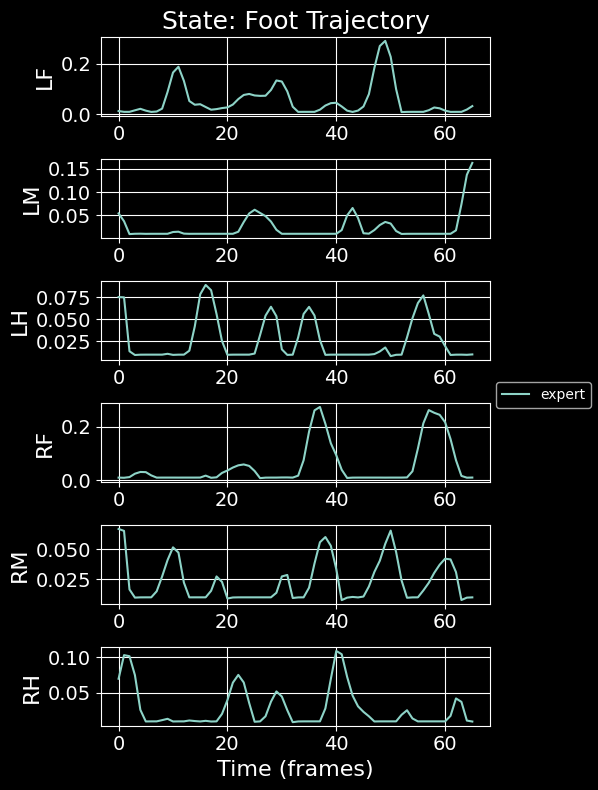

In [23]:
def plot_6_legs(expert, variable_name, start, end, title):
    fig, axs = plt.subplots(6, 1, figsize=(6, 8))
    expert_data = expert[variable_name].values
    ylabel = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']
    for i in range(6):
        axs[i].plot(expert_data[start:end, i], label="expert")
        axs[i].set_ylabel(ylabel[i], fontsize=16)
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].grid()
    axs[0].set_title(title, fontsize=18)
    axs[-1].set_xlabel('Time (frames)', fontsize=16)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=10, ncol=1, loc='outside center right')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

plot_6_legs(data, ['FL_foot_traj_z', 'ML_foot_traj_z', 'HL_foot_traj_z', 'FR_foot_traj_z', 'MR_foot_traj_z', 'HR_foot_traj_z'], 0, len(data), 'State: Foot Trajectory')

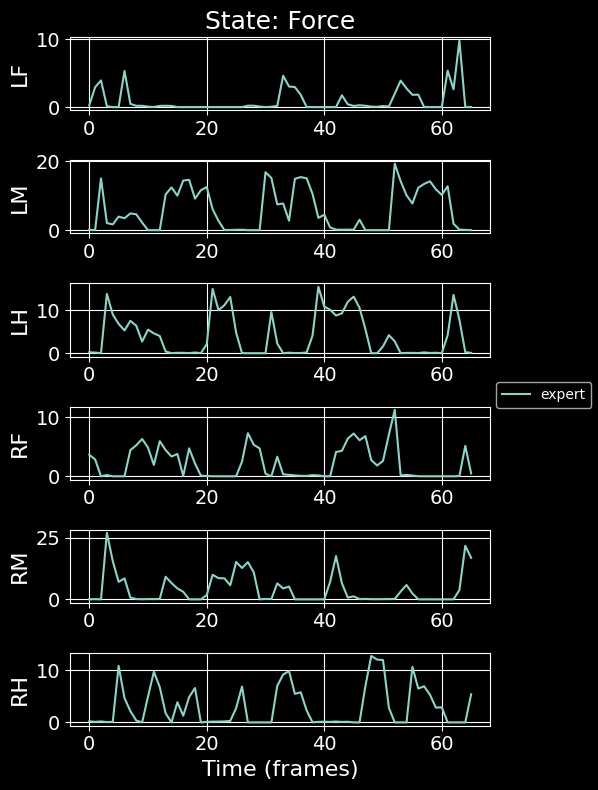

In [22]:
def plot_6_legs(expert, variable_name, start, end, title):
    fig, axs = plt.subplots(6, 1, figsize=(6, 8))
    expert_data = expert[variable_name].values
    ylabel = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']
    for i in range(6):
        axs[i].plot(expert_data[start:end, i], label="expert")
        axs[i].set_ylabel(ylabel[i], fontsize=16)
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].grid()
    axs[0].set_title(title, fontsize=18)
    axs[-1].set_xlabel('Time (frames)', fontsize=16)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=10, ncol=1, loc='outside center right')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

plot_6_legs(data, ['force_FL', 'force_ML', 'force_HL', 'force_FR', 'force_MR', 'force_HR'], 0, len(data), 'State: Force')